Name: Christopher A. Lee\
Date: 04/21/2026\
Prof: Dr. Azarnoosh\
Course: Machine Learning for Data Analysis - ENBC 321

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# Set seed
random.seed(321)

In [3]:
# Import data
df = pd.read_csv('bio_data.csv')
print(df.head())

     Gene_0    Gene_1    Gene_2    Gene_3    Gene_4    Gene_5    Gene_6  \
0  0.496714 -0.138264  0.647689  1.523030 -0.234153 -0.234137  1.579213   
1  1.465649 -0.225776  0.067528 -1.424748 -0.544383  0.110923 -1.150994   
2  0.738467  0.171368 -0.115648 -0.301104 -1.478522 -0.719844 -0.460639   
3 -0.479174 -0.185659 -1.106335 -1.196207  0.812526  1.356240 -0.072010   
4 -0.219672  0.357113  1.477894 -0.518270 -0.808494 -0.501757  0.915402   

     Gene_7    Gene_8    Gene_9  ...   Gene_12   Gene_13   Gene_14   Gene_15  \
0  0.767435 -0.469474  0.542560  ...  0.241962 -1.913280 -1.724918 -0.562288   
1  0.375698 -0.600639 -0.291694  ... -0.013497 -1.057711  0.822545 -1.220844   
2  1.057122  0.343618 -1.763040  ... -0.676922  0.611676  1.031000  0.931280   
3  1.003533  0.361636 -0.645120  ... -0.035826  1.564644 -2.619745  0.821903   
4  0.328751 -0.529760  0.513267  ... -0.702053 -0.327662 -0.392108 -1.463515   

    Gene_16   Gene_17   Gene_18   Gene_19  Protein_Concentration  \


In [4]:
# Preprocess data
X = df.drop(columns=['Protein_Concentration', 'Cancer_Status'])
y1, y2 = df.iloc[:, -2], df.iloc[:, -1]

# Train test split the data
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=321)
X2_train, X2_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=321)

# Scale data
scaler1 = StandardScaler()
scaler2 = StandardScaler()

X1_train_scaled, X1_test_scaled = scaler1.fit_transform(X1_train), scaler1.transform(X1_test)
X2_train_scaled, X2_test_scaled = scaler2.fit_transform(X2_train), scaler2.transform(X2_test)



MLP Regressor R^2 Score Training Set: 0.9916994535830911
MLP Regressor R^2 Score Test Set: 0.9799634282557751


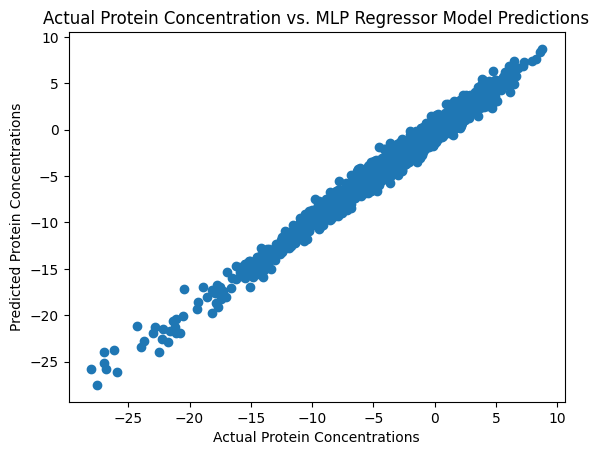

In [5]:
# Train and Evaluate Regression ANN
model_mlpr = MLPRegressor(max_iter=500).fit(X1_train_scaled, y1_train)
model_mlpr_pred_train = model_mlpr.predict(X1_train_scaled)
model_mlpr_pred_test = model_mlpr.predict(X1_test_scaled)
print("MLP Regressor R^2 Score Training Set:", r2_score(y1_train, model_mlpr_pred_train))
print("MLP Regressor R^2 Score Test Set:", r2_score(y1_test, model_mlpr_pred_test))

# Plot Predictions
plt.scatter(y1_test, model_mlpr_pred_test)
plt.title("Actual Protein Concentration vs. MLP Regressor Model Predictions")
plt.xlabel("Actual Protein Concentrations")
plt.ylabel("Predicted Protein Concentrations")
plt.show()

In [6]:
# Train and Evaluate Classifier ANN
model_mlpc = MLPClassifier(max_iter=5000).fit(X2_train_scaled, y2_train)
model_mlpc_pred = model_mlpc.predict(X2_test_scaled)
print("MLP Classifier Accuracy Score:", accuracy_score(y2_test, model_mlpc_pred))
print("MLP Classifier Confusion Matrix:\n", confusion_matrix(y2_test, model_mlpc_pred))

MLP Classifier Accuracy Score: 0.8315
MLP Classifier Confusion Matrix:
 [[ 305  158]
 [ 179 1358]]


In [7]:
print("1. Activation functions determine whether or not the current inputs that it is receiving are sufficent enough to pass \nonto the next layer. Without activation functions, it would result in a linear transformation and not be able to capture \ncomplex relationships between the features of a dataset.")
print("2. It indicates the model is overfitting or memorizing the training data, causing its ability to generalize its predictions \nto unforseen data very hard.")
print("3. The type of activation function for each layer, number of hidden layers, number of nodes, and learning rate.")

1. Activation functions determine whether or not the current inputs that it is receiving are sufficent enough to pass 
onto the next layer. Without activation functions, it would result in a linear transformation and not be able to capture 
complex relationships between the features of a dataset.
2. It indicates the model is overfitting or memorizing the training data, causing its ability to generalize its predictions 
to unforseen data very hard.
3. The type of activation function for each layer, number of hidden layers, number of nodes, and learning rate.
